In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error , r2_score

In [2]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["price"] = housing.target


In [3]:
x=data[["AveRooms"]].values
y=data["price"].values


In [4]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.fit_transform(X_test)

In [6]:
w=0
b=0

learning_rate = 0.01
epochs = 1000

n=len(X_train_scaled)

for i in range(epochs):
    y_pred = w*X_train_scaled.flatten() + b
    dw = (1/n)*np.sum((y_pred-y_train)*X_train_scaled.flatten())
    db = (1/n)*np.sum(y_pred-y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost=(1/(2*n))*np.sum((y_pred-y_train)**2)
        print(f"Epoch {i},Cost ={cost:.4f}")

y_pred_gd = w*X_test_scaled.flatten() + b

Epoch 0,Cost =2.8149
Epoch 100,Cost =0.9414
Epoch 200,Cost =0.6904
Epoch 300,Cost =0.6568
Epoch 400,Cost =0.6523
Epoch 500,Cost =0.6517
Epoch 600,Cost =0.6516
Epoch 700,Cost =0.6516
Epoch 800,Cost =0.6516
Epoch 900,Cost =0.6516


In [7]:
print("Gradient Descent")
print("________________")
print("Weights:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 Score:",r2_score(y_test,y_pred_gd))

Gradient Descent
________________
Weights: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.2893422211238508
R2 Score: 0.016076474953131803


In [16]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]
theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

In [18]:
print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("slope:",theta[1])
print("MSE:",mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


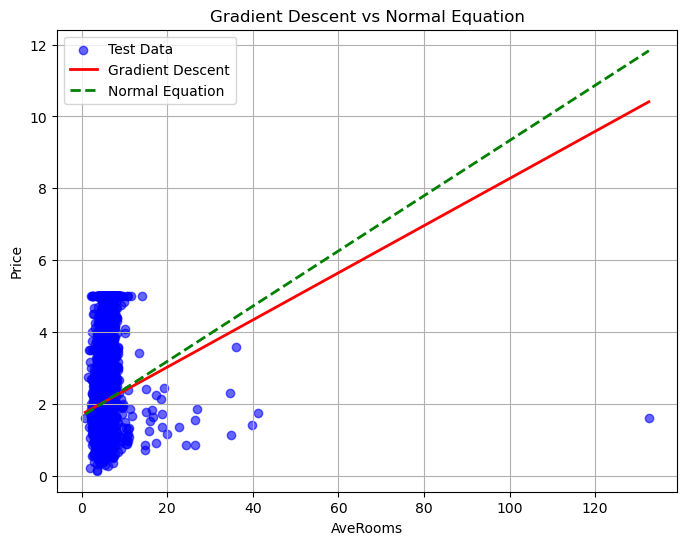

In [21]:

plt.figure(figsize=(8,6))
X_sort = np.sort(X_test, axis=0)

w_org = w / scaler.scale_[0]
b_org = b - (w * scaler.mean_[0] / scaler.scale_[0])
y_gd = w_org * X_sort + b_org
y_ne = theta[0] + theta[1] * X_sort

plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Test Data')
plt.plot(X_sort, y_gd, color='red', linewidth=2, label='Gradient Descent')
plt.plot(X_sort, y_ne, color='green', linestyle='--', linewidth=2, label='Normal Equation')

plt.title("Gradient Descent vs Normal Equation")
plt.xlabel("AveRooms")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()